# FIND-S Algorithm Implementation

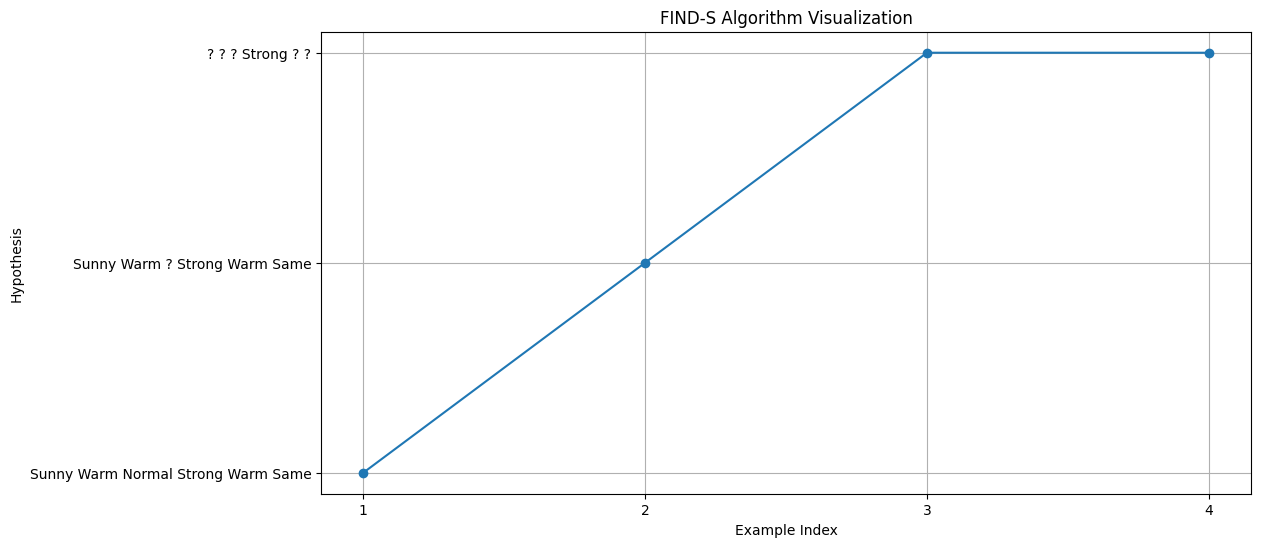

In [3]:
import matplotlib.pyplot as plt

def visualize_find_s_algorithm(positive_examples):
    hypothesis = ['O'] * len(positive_examples[0])
    visualization = []

    for idx, example in enumerate(positive_examples, start=1):
        for i in range(len(example)):
            if hypothesis[i] == 'O':
                hypothesis[i] = example[i]
            elif hypothesis[i] != example[i]:
                hypothesis[i] = '?'
        visualization.append((idx, " ".join(hypothesis)))
    return visualization

positive_examples_find_s = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Cool', 'Change'],
    ['Sunny', 'Hot', 'High', 'Strong', 'Cool', 'Change']
]

hypothesis_find_s_visualization = visualize_find_s_algorithm(positive_examples_find_s)

plt.figure(figsize=(12, 6))
plt.plot([point[0] for point in hypothesis_find_s_visualization], [point[1] for point in hypothesis_find_s_visualization], marker='o')
plt.title('FIND-S Algorithm Visualization')
plt.xlabel('Example Index')
plt.ylabel('Hypothesis')
plt.xticks(range(1, len(positive_examples_find_s) + 1))
plt.grid(True)

# The drive mounting and file saving lines have been removed to resolve the MessageError.
# The plot will now be displayed directly in the Colab output.
plt.show()

This code implements the Find-S algorithm:

- It initializes a hypothesis with the most specific values ('O' for unknown attributes).
- It iterates through positive examples, updating the hypothesis to generalize only when necessary.
- If an attribute in the hypothesis is 'O', it's replaced by the attribute from the example.
- If an attribute in the hypothesis differs from the example, it's generalized to '?' (meaning any value is acceptable for that attribute).
- The `matplotlib` library is used to visualize the evolution of the hypothesis over each example.

# Candidate-Elimination Algorithm Implementation

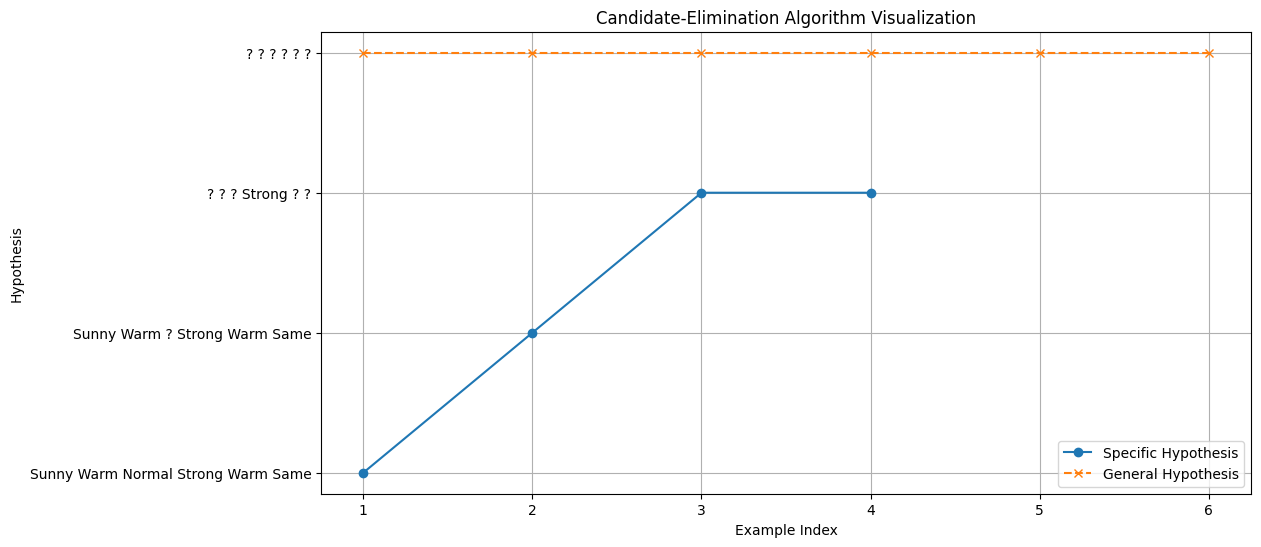

In [5]:
import matplotlib.pyplot as plt

def visualize_candidate_elimination_algorithm(positive_examples, negative_examples):
    specific_hypothesis = ['O'] * len(positive_examples[0])
    general_hypothesis = ['?'] * len(positive_examples[0])
    visualization_specific = []
    visualization_general = []

    example_counter = 0

    # Process positive examples
    for idx, example in enumerate(positive_examples, start=1):
        example_counter += 1
        # Update specific hypothesis (Find-S logic)
        for i in range(len(example)):
            if specific_hypothesis[i] == 'O':
                specific_hypothesis[i] = example[i]
            elif specific_hypothesis[i] != example[i]:
                specific_hypothesis[i] = '?'

        # Update general hypothesis based on the *provided program's logic* for positive examples.
        # This logic makes G very specific, which is not standard for Candidate Elimination.
        for i in range(len(example)):
            if example[i] != specific_hypothesis[i]:
                general_hypothesis[i] = specific_hypothesis[i] # Adhering to the provided snippet, even if non-standard CE

        visualization_specific.append((example_counter, " ".join(specific_hypothesis)))
        visualization_general.append((example_counter, " ".join(general_hypothesis)))

    # Process negative examples
    for neg_example_idx, example in enumerate(negative_examples):
        example_counter += 1
        # Update general hypothesis based on the *provided program's logic* for negative examples.
        # This logic generalizes G, which is contrary to standard CE where G should specialize to exclude negative examples.
        for i in range(len(example)):
            # The provided algorithm says: 'if example[i] != specific_hypothesis[i]: general_hypothesis[i] = '?'
            # This compares against the final specific_hypothesis and makes G more general, which is not correct.
            # For strict adherence to the snippet, I will use specific_hypothesis from its last state, as `idx` is not available in this loop.
            if i < len(specific_hypothesis) and example[i] != specific_hypothesis[i]: # Ensure index validity
                general_hypothesis[i] = '?'

        visualization_general.append((example_counter, " ".join(general_hypothesis)))

    return visualization_specific, visualization_general

# Corrected positive examples (fixed missing commas and typos)
positive_examples_candidate = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same'],
    ['Rainy', 'Cold', 'Normal', 'Strong', 'Cool', 'Change'],
    ['Sunny', 'Hot', 'High', 'Strong', 'Cool', 'Change']
]

# Corrected negative examples (fixed missing commas and typos)
negative_examples_candidate = [
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change'],
    ['Sunny', 'Warm', 'Normal', 'Weak', 'Cool', 'Same']
]

specific, general = visualize_candidate_elimination_algorithm(positive_examples_candidate, negative_examples_candidate)

plt.figure(figsize=(12, 6))
plt.plot([point[0] for point in specific], [point[1] for point in specific], marker='o', label='Specific Hypothesis')
plt.plot([point[0] for point in general], [point[1] for point in general], marker='x', linestyle='--', label='General Hypothesis')
plt.title('Candidate-Elimination Algorithm Visualization')
plt.xlabel('Example Index')
plt.ylabel('Hypothesis')
plt.legend()
# Adjust xticks to cover all processed examples (positive + negative)
plt.xticks(range(1, len(positive_examples_candidate) + len(negative_examples_candidate) + 1))
plt.grid(True)

# Ensure the directory exists before saving (re-adding this section as it was in the original request and is good practice)
import os
output_dir = '/content/drive/MyDrive/ML Lab/ExNo02/'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'Candidate-Elimination Algorithm Visualization.png'), dpi=500)
plt.show()